# Checkpoint 1: PR Merge Outcomes on GitHub

This notebook presents the first checkpoint analysis for the ADES project. The goal is to assess whether PR-level features can help explain merge outcomes on GitHub, using the PRFeatures training split as the main analytical dataset and the provided test split only to confirm schema and target consistency. The emphasis here is on understanding the data, screening risky features, and surfacing the clearest early patterns before any modeling work begins.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
EDA_PLOT_SAMPLE = 50000
TARGET_COLUMN = "merged_or_not"
TARGET_LABELS = {0: "Not merged", 1: "Merged"}


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "data" / "raw").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the notebook directory.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
TRAIN_PATH = DATA_DIR / "prfeatures_train_data.csv"
TEST_PATH = DATA_DIR / "prfeatures_test_data.csv"


## Data and scope

The PRFeatures training split is the main analytical dataset. The PRFeatures test split is loaded only to confirm that the schema and target definition match. The comments dataset and survey dataset stay out of this checkpoint so the analysis stays focused on PR-level predictors.


In [2]:
scope_df = pd.DataFrame(
    [
        {"dataset": "prfeatures_train_data.csv", "role": "Main analysis dataset", "used_now": True},
        {"dataset": "prfeatures_test_data.csv", "role": "Schema and target consistency check", "used_now": True},
        {"dataset": "pr_comments_dataset_publish.csv", "role": "Excluded from this checkpoint", "used_now": False},
        {"dataset": "survey_responses_raw.csv", "role": "Excluded as project basis", "used_now": False},
    ]
)

display(scope_df)


,dataset,role,used_now
0,prfeatures_train_data.csv,Main analysis dataset,True
1,prfeatures_test_data.csv,Schema and target consistency check,True
2,pr_comments_dataset_publish.csv,Excluded from this checkpoint,False
3,survey_responses_raw.csv,Excluded as project basis,False


## Target audit

Before looking at feature patterns, the notebook checks that train and test use the same PR-level schema, that `merged_or_not` is present in both files, and that the merge outcome is heavily imbalanced.


,check,result
0,train rows,"1,045,883"
1,test rows,"260,195"
2,train columns,72
3,test columns,72
4,same column names,True
5,same column order,True
6,target in train,True
7,target in test,True
8,explicit nulls in train,0
9,explicit nulls in test,0


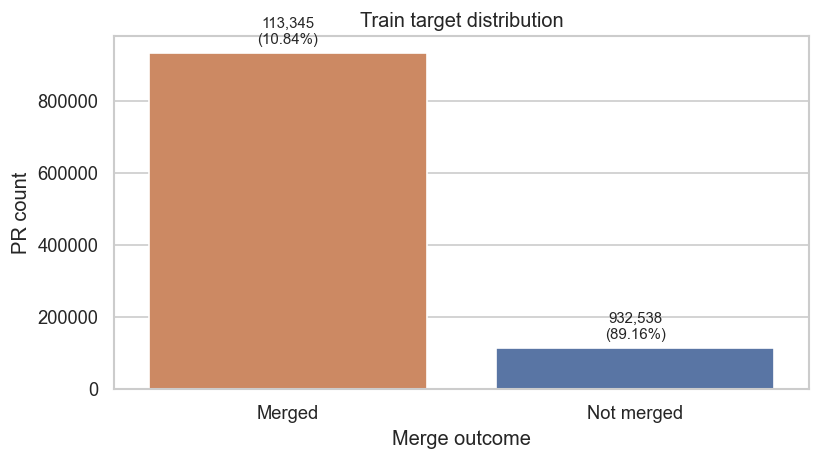

In [3]:
train_df = pd.read_csv(TRAIN_PATH, low_memory=False)
test_df = pd.read_csv(TEST_PATH, low_memory=False)

same_column_names = set(train_df.columns) == set(test_df.columns)
same_column_order = train_df.columns.equals(test_df.columns)
train_nulls = int(train_df.isna().sum().sum())
test_nulls = int(test_df.isna().sum().sum())
train_duplicates = int(train_df.duplicated().sum())
test_duplicates = int(test_df.duplicated().sum())


def build_target_distribution(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    counts = df[TARGET_COLUMN].value_counts().sort_index()
    percentages = (counts / len(df) * 100).round(2)
    return pd.DataFrame(
        {
            "split": split_name,
            "target_value": counts.index,
            "label": [TARGET_LABELS[value] for value in counts.index],
            "count": counts.values,
            "percentage": percentages.values,
        }
    )


target_distribution_train = build_target_distribution(train_df, "train")
target_distribution_test = build_target_distribution(test_df, "test")
target_distribution = pd.concat([target_distribution_train, target_distribution_test], ignore_index=True)

audit_summary = pd.DataFrame(
    [
        {"check": "train rows", "result": f"{train_df.shape[0]:,}"},
        {"check": "test rows", "result": f"{test_df.shape[0]:,}"},
        {"check": "train columns", "result": train_df.shape[1]},
        {"check": "test columns", "result": test_df.shape[1]},
        {"check": "same column names", "result": same_column_names},
        {"check": "same column order", "result": same_column_order},
        {"check": "target in train", "result": TARGET_COLUMN in train_df.columns},
        {"check": "target in test", "result": TARGET_COLUMN in test_df.columns},
        {"check": "explicit nulls in train", "result": train_nulls},
        {"check": "explicit nulls in test", "result": test_nulls},
        {"check": "duplicate rows in train", "result": train_duplicates},
        {"check": "duplicate rows in test", "result": test_duplicates},
    ]
)

display(audit_summary)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=target_distribution_train,
    x="label",
    y="count",
    hue="label",
    order=["Merged", "Not merged"],
    palette=["#4C72B0", "#DD8452"],
    legend=False,
    ax=ax,
)
ax.set_title("Train target distribution")
ax.set_xlabel("Merge outcome")
ax.set_ylabel("PR count")
ordered_rows = target_distribution_train.set_index("label").loc[["Merged", "Not merged"]].reset_index()
for patch, (_, row) in zip(ax.patches, ordered_rows.iterrows()):
    ax.annotate(
        f"{int(row['count']):,}\n({row['percentage']:.2f}%)",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 4),
        textcoords="offset points",
    )
plt.tight_layout()
plt.show()


## Leakage-aware feature selection

The feature review separates identifiers, clearly post-outcome variables, timing-sensitive variables that need more justification, and the subset used for early descriptive analysis. The goal is to avoid mixing obviously unsafe features into the first round of interpretation.


In [4]:
exclude_ids = [
    "id",
    "project_id",
    "creator_id",
    "last_closer_id",
]

exclude_post_outcome = [
    "last_close_time",
    "lifetime_minutes",
    "reopen_or_not",
]

ambiguous_features = [
    "num_comments",
    "has_comments",
    "num_participants",
    "core_comment",
    "contrib_comment",
    "inte_comment",
    "has_exchange",
    "at_tag",
    "num_code_comments",
    "num_code_comments_con",
    "perc_neg_emotion",
    "perc_pos_emotion",
    "comment_conflict",
    "contrib_open",
    "contrib_cons",
    "contrib_extra",
    "contrib_agree",
    "contrib_neur",
    "inte_open",
    "inte_cons",
    "inte_extra",
    "inte_agree",
    "inte_neur",
    "perc_contrib_pos_emo",
    "perc_contrib_neg_emo",
    "perc_inte_pos_emo",
    "perc_inte_neg_emo",
    "social_strength",
    "same_user",
    "ci_build_num",
    "ci_failed_perc",
    "integrator_availability",
]

candidate_safe_features = [
    "first_pr",
    "prior_review_num",
    "core_member",
    "prior_interaction",
    "followers",
    "prev_pullreqs",
    "account_creation_days",
    "contrib_perc_commit",
    "sloc",
    "team_size",
    "language",
    "open_issue_num",
    "project_age",
    "open_pr_num",
    "fork_num",
    "pr_succ_rate",
    "test_lines_per_kloc",
    "stars",
    "test_cases_per_kloc",
    "asserts_per_kloc",
    "perc_external_contribs",
    "requester_succ_rate",
    "churn_addition",
    "churn_deletion",
    "description_length",
    "test_inclusion",
    "ci_exists",
    "test_churn",
    "num_commits",
    "src_churn",
    "files_changed",
    "friday_effect",
]

feature_group_summary = pd.DataFrame(
    [
        {
            "group": "Identifiers",
            "count": len(exclude_ids),
            "examples": ", ".join(exclude_ids[:3]),
            "use_now": "Exclude",
        },
        {
            "group": "Post-outcome features",
            "count": len(exclude_post_outcome),
            "examples": ", ".join(exclude_post_outcome),
            "use_now": "Exclude",
        },
        {
            "group": "Timing-sensitive features",
            "count": len(ambiguous_features),
            "examples": ", ".join(ambiguous_features[:3]),
            "use_now": "Hold back",
        },
        {
            "group": "Early EDA features",
            "count": len(candidate_safe_features),
            "examples": ", ".join(candidate_safe_features[:4]),
            "use_now": "Use for descriptive analysis",
        },
    ]
)

display(feature_group_summary)


,group,count,examples,use_now
0,Identifiers,4,"id, project_id, creator_id",Exclude
1,Post-outcome features,3,"last_close_time, lifetime_minutes, reopen_or_not",Exclude
2,Timing-sensitive features,32,"num_comments, has_comments, num_participants",Hold back
3,Early EDA features,32,"first_pr, prior_review_num, core_member, prior...",Use for descriptive analysis


## Initial exploratory analysis

The early EDA stays on the lower-risk feature subset. The tables below compare a few interpretable size and contributor variables, and the plot focuses on how larger PRs tend to appear more often among non-merged outcomes. `language` remains a categorical code and is not treated as an ordered numeric scale.


,feature,mean_not_merged,mean_merged,median_not_merged,median_merged
0,files_changed,15.441,10.908,2.000,2.000
1,churn_addition,618.555,412.572,22.000,16.000
2,description_length,59.919,45.953,26.000,20.000
3,num_commits,4.696,3.984,2.000,2.000


,feature,value,count,merge_rate_pct
0,first_pr,0,1012149,89.450
1,first_pr,1,33734,80.680
2,core_member,0,206724,82.560
3,core_member,1,839159,90.790
4,test_inclusion,0,825940,89.430
5,test_inclusion,1,219943,88.170
6,friday_effect,0,872033,89.110
7,friday_effect,1,173850,89.420


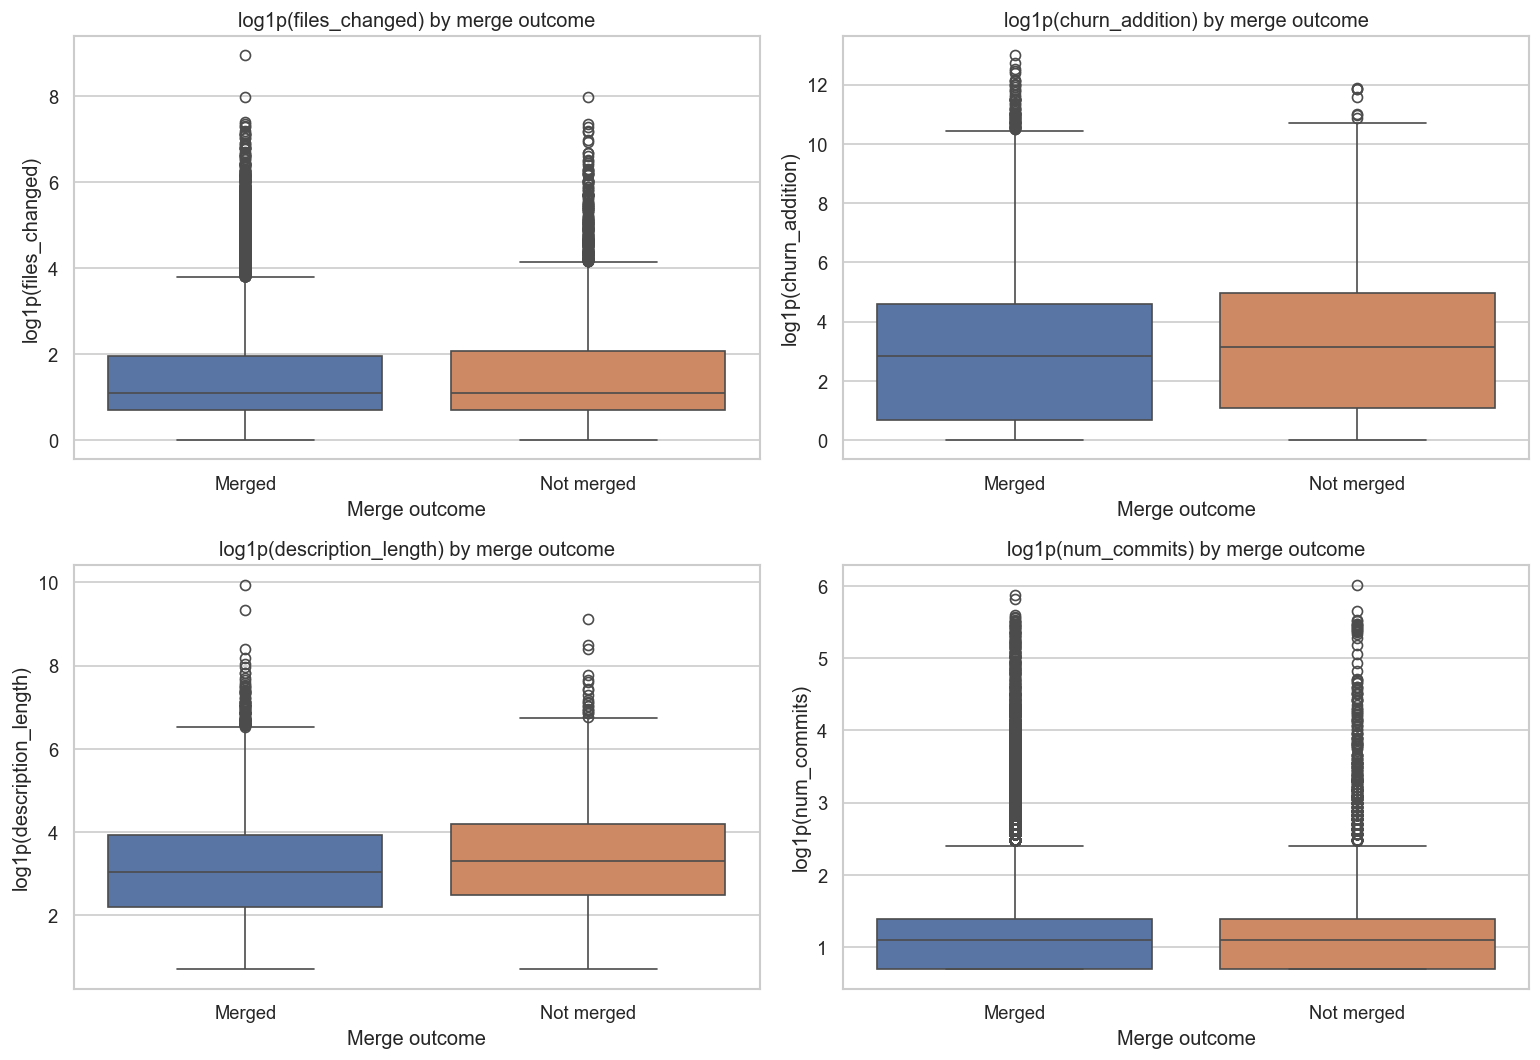

In [5]:
eda_focus_features = [
    "first_pr",
    "core_member",
    "test_inclusion",
    "friday_effect",
    "files_changed",
    "churn_addition",
    "description_length",
    "num_commits",
]

grouped_feature_summary = pd.DataFrame(
    [
        {
            "feature": feature_name,
            "mean_not_merged": train_df.loc[train_df[TARGET_COLUMN] == 0, feature_name].mean(),
            "mean_merged": train_df.loc[train_df[TARGET_COLUMN] == 1, feature_name].mean(),
            "median_not_merged": train_df.loc[train_df[TARGET_COLUMN] == 0, feature_name].median(),
            "median_merged": train_df.loc[train_df[TARGET_COLUMN] == 1, feature_name].median(),
        }
        for feature_name in ["files_changed", "churn_addition", "description_length", "num_commits"]
    ]
).round(3)

categorical_merge_rates = pd.concat(
    [
        train_df.groupby(feature_name)[TARGET_COLUMN]
        .agg(merge_rate="mean", count="size")
        .reset_index()
        .rename(columns={feature_name: "value"})
        .assign(feature=feature_name, merge_rate_pct=lambda df: (df["merge_rate"] * 100).round(2))
        for feature_name in ["first_pr", "core_member", "test_inclusion", "friday_effect"]
    ],
    ignore_index=True,
)[["feature", "value", "count", "merge_rate_pct"]]

display(grouped_feature_summary)
display(categorical_merge_rates)

plot_sample = train_df[
    ["files_changed", "churn_addition", "description_length", "num_commits", TARGET_COLUMN]
].sample(n=min(EDA_PLOT_SAMPLE, len(train_df)), random_state=RANDOM_STATE)
plot_sample["merge_label"] = plot_sample[TARGET_COLUMN].map(TARGET_LABELS)

for feature_name in ["files_changed", "churn_addition", "description_length", "num_commits"]:
    plot_sample[f"log1p_{feature_name}"] = np.log1p(plot_sample[feature_name])

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feature_name in zip(
    axes.flatten(),
    ["files_changed", "churn_addition", "description_length", "num_commits"],
):
    sns.boxplot(
        data=plot_sample,
        x="merge_label",
        y=f"log1p_{feature_name}",
        hue="merge_label",
        order=["Merged", "Not merged"],
        palette=["#4C72B0", "#DD8452"],
        dodge=False,
        legend=False,
        ax=ax,
    )
    ax.set_title(f"log1p({feature_name}) by merge outcome")
    ax.set_xlabel("Merge outcome")
    ax.set_ylabel(f"log1p({feature_name})")
plt.tight_layout()
plt.show()


## Key findings


In [6]:
train_merged_row = target_distribution_train.loc[target_distribution_train["target_value"] == 1].iloc[0]
train_not_merged_row = target_distribution_train.loc[target_distribution_train["target_value"] == 0].iloc[0]

first_pr_merge_rate = categorical_merge_rates.query("feature == 'first_pr' and value == 1")["merge_rate_pct"].iloc[0]
repeat_pr_merge_rate = categorical_merge_rates.query("feature == 'first_pr' and value == 0")["merge_rate_pct"].iloc[0]
core_member_merge_rate = categorical_merge_rates.query("feature == 'core_member' and value == 1")["merge_rate_pct"].iloc[0]
non_core_member_merge_rate = categorical_merge_rates.query("feature == 'core_member' and value == 0")["merge_rate_pct"].iloc[0]

files_changed_not_merged = grouped_feature_summary.loc[grouped_feature_summary["feature"] == "files_changed", "mean_not_merged"].iloc[0]
files_changed_merged = grouped_feature_summary.loc[grouped_feature_summary["feature"] == "files_changed", "mean_merged"].iloc[0]
churn_addition_not_merged = grouped_feature_summary.loc[grouped_feature_summary["feature"] == "churn_addition", "mean_not_merged"].iloc[0]
churn_addition_merged = grouped_feature_summary.loc[grouped_feature_summary["feature"] == "churn_addition", "mean_merged"].iloc[0]
description_not_merged = grouped_feature_summary.loc[grouped_feature_summary["feature"] == "description_length", "mean_not_merged"].iloc[0]
description_merged = grouped_feature_summary.loc[grouped_feature_summary["feature"] == "description_length", "mean_merged"].iloc[0]

display(
    Markdown(
        f'''
- Train and test are consistent at the PR-feature level: both files contain 72 columns in the same order, and both include `{TARGET_COLUMN}`.
- The target is strongly imbalanced in the training split: {train_merged_row['percentage']:.2f}% merged versus {train_not_merged_row['percentage']:.2f}% not merged.
- The feature screen keeps 4 identifier fields and 3 clearly post-outcome fields out of the early analysis, while 32 timing-sensitive variables remain under review.
- In the early descriptive pass, non-merged PRs are larger on average for `files_changed` ({files_changed_not_merged:.2f} vs {files_changed_merged:.2f}), `churn_addition` ({churn_addition_not_merged:.2f} vs {churn_addition_merged:.2f}), and `description_length` ({description_not_merged:.2f} vs {description_merged:.2f}).
- Contributor context also differs: first-time PRs merge less often than repeat PRs ({first_pr_merge_rate:.2f}% vs {repeat_pr_merge_rate:.2f}%), and non-core-member PRs merge less often than core-member PRs ({non_core_member_merge_rate:.2f}% vs {core_member_merge_rate:.2f}%).
        '''
    )
)



- Train and test are consistent at the PR-feature level: both files contain 72 columns in the same order, and both include `merged_or_not`.
- The target is strongly imbalanced in the training split: 89.16% merged versus 10.84% not merged.
- The feature screen keeps 4 identifier fields and 3 clearly post-outcome fields out of the early analysis, while 32 timing-sensitive variables remain under review.
- In the early descriptive pass, non-merged PRs are larger on average for `files_changed` (15.44 vs 10.91), `churn_addition` (618.55 vs 412.57), and `description_length` (59.92 vs 45.95).
- Contributor context also differs: first-time PRs merge less often than repeat PRs (80.68% vs 89.45%), and non-core-member PRs merge less often than core-member PRs (82.56% vs 90.79%).
        

## Next steps for Checkpoint 2

- Finalize the first modeling-ready feature subset and revisit only the ambiguous variables whose timing can be justified clearly.
- Build a reproducible preprocessing pipeline for binary, numeric, rate, and categorical variables.
- Use imbalance-aware metrics and baselines instead of relying on raw accuracy.
- Keep the provided test split untouched for later evaluation while continuing exploration on the training data.
